In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

In [3]:

df = pd.read_csv('all_bikez_curated.csv')
print(f"تعداد موتورسیکلت: {len(df)} تا")
print(f"تعداد ستون: {df.shape[1]} تا")
df.head(3)

تعداد موتورسیکلت: 38472 تا
تعداد ستون: 28 تا


C:\Users\mahyar\AppData\Local\Temp\ipykernel_11504\219003834.py:1: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('all_bikez_curated.csv')


,Brand,Model,Year,Category,Rating,Displacement (ccm),Power (hp),Torque (Nm),Engine cylinder,Engine stroke,...,Dry weight (kg),Wheelbase (mm),Seat height (mm),Front brakes,Rear brakes,Front tire,Rear tire,Front suspension,Rear suspension,Color options
0,acabion,da vinci 650-vi,2011,Prototype / concept model,3.2,NaN,804.0,NaN,Electric,Electric,...,420.0,NaN,NaN,Single disc,Single disc,NaN,NaN,NaN,NaN,NaN
1,acabion,gtbo 55,2007,Sport,2.6,1300.0,541.0,420.0,In-line four,four-stroke,...,360.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,acabion,gtbo 600 daytona-vi,2011,Prototype / concept model,3.5,NaN,536.0,NaN,Electric,Electric,...,420.0,NaN,NaN,Single disc,Single disc,NaN,NaN,NaN,NaN,NaN


In [11]:
# اطلاعات کلی دیتاست!
print("اطلاعات دیتاست:")
df.info()

print("\nآمار عددی ستون‌ها:")
df.describe()

اطلاعات دیتاست:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38472 entries, 0 to 38471
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Brand                38472 non-null  object 
 1   Model                38444 non-null  object 
 2   Year                 38472 non-null  int64  
 3   Category             38472 non-null  object 
 4   Rating               21788 non-null  float64
 5   Displacement (ccm)   37461 non-null  float64
 6   Power (hp)           26110 non-null  float64
 7   Torque (Nm)          16634 non-null  float64
 8   Engine cylinder      38461 non-null  object 
 9   Engine stroke        38461 non-null  object 
 10  Gearbox              32675 non-null  object 
 11  Bore (mm)            28689 non-null  float64
 12  Stroke (mm)          28689 non-null  object 
 13  Fuel capacity (lts)  31704 non-null  float64
 14  Fuel system          27844 non-null  object 
 15  Fuel control        

,Year,Rating,Displacement (ccm),Power (hp),Torque (Nm),Bore (mm),Fuel capacity (lts),Dry weight (kg),Wheelbase (mm),Seat height (mm)
count,38472.000000,21788.000000,37461.000000,26110.000000,16634.000000,28689.000000,31704.000000,22483.000000,25493.000000,24182.000000
mean,2003.195883,3.401574,552.515072,50.776040,64.527173,72.596713,13.286191,164.151532,1423.113521,789.253246
std,20.083372,0.355631,545.394956,52.082094,63.884654,18.758621,6.010670,85.085133,172.645438,105.492167
min,1894.000000,1.400000,25.000000,0.300000,1.500000,1.000000,0.500000,15.100000,725.000000,39.000000
25%,2000.000000,3.200000,125.000000,12.000000,12.200000,57.000000,8.200000,105.000000,1321.000000,743.000000
50%,2010.000000,3.400000,397.200000,30.000000,57.000000,73.000000,13.500000,145.000000,1422.000000,790.000000
75%,2016.000000,3.700000,805.000000,77.000000,102.000000,88.000000,17.500000,199.600000,1500.000000,830.000000
max,2022.000000,4.600000,8277.000000,804.000000,712.000000,176.000000,64.340000,1000.000000,3327.000000,7501.000000


درصد داده‌های گم شده:
Torque (Nm)            56.763360
Rating                 43.366604
Fuel control           42.794760
Dry weight (kg)        41.560096
Seat height (mm)       37.143897
Color options          36.766999
Wheelbase (mm)         33.736224
Rear suspension        33.614057
Front suspension       32.140258
Power (hp)             32.132460
Fuel system            27.625286
Bore (mm)              25.428883
Stroke (mm)            25.428883
Fuel capacity (lts)    17.592015
Front tire             16.869412
Rear tire              16.801830
Gearbox                15.068101
Transmission type      14.584633
Cooling system         10.953421
Rear brakes             4.616344
Front brakes            4.114681
Displacement (ccm)      2.627885
Model                   0.072780
Engine cylinder         0.028592
Engine stroke           0.028592
dtype: float64


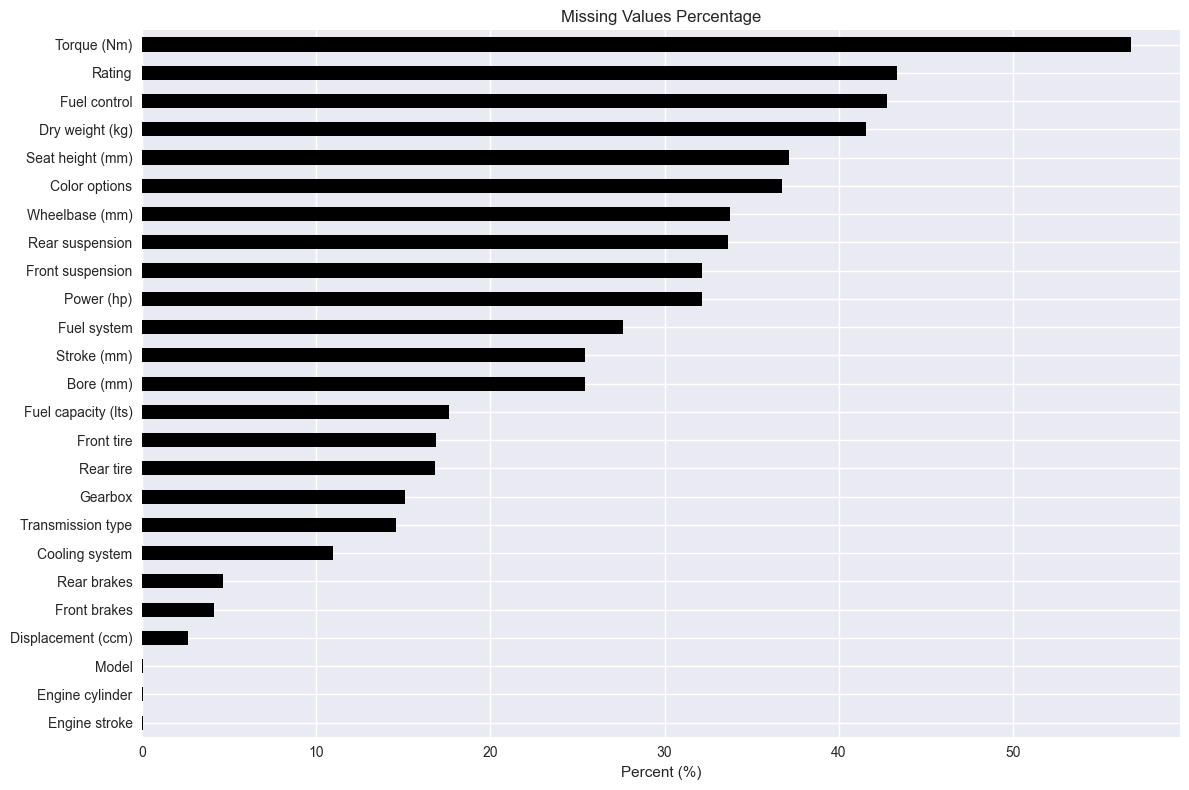

In [12]:
# چند درصد از هر ستون خالیه؟
print("درصد داده‌های گم شده:")
missing = df.isnull().mean() * 100
print(missing[missing > 0].sort_values(ascending=False))

# نمودار میله‌ای گم شده‌ها
missing[missing > 0].sort_values().plot(kind='barh', color='black')
plt.title('Missing Values Percentage')
plt.xlabel('Percent (%)')
plt.tight_layout()
plt.savefig('missing_values.png', dpi=300, bbox_inches='tight')
plt.show()

In [4]:
# نمونه مشکل: عدد با کاما نوشته شده → پانداس فکر می‌کنه متنه!


# تابع پاک کردن کاما
def clean_numeric(x):
    if isinstance(x, str):
        return float(x.replace(',', ''))
    return x

# اعمال روی همه ستون‌های عددی
numeric_cols = ['Year', 'Displacement (ccm)', 'Power (hp)', 'Torque (Nm)', 
                'Dry weight (kg)', 'Bore (mm)', 'Stroke (mm)', 
                'Fuel capacity (lts)', 'Wheelbase (mm)', 'Seat height (mm)']

for col in numeric_cols:
    df[col] = df[col].apply(clean_numeric)

print(" همه عدد شدن!")

 همه عدد شدن!


In [14]:
# روش اول: پر کردن با میانه (Median) — برای داده‌های عددی خوبه
for col in numeric_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

print("همه داده‌های عددی با میانه پر شدن")

همه داده‌های عددی با میانه پر شدن


In [15]:
# ستون‌های متنی رو با Unknown پر می‌کنیم
cat_cols = ['Brand', 'Category', 'Engine cylinder', 'Engine stroke', 'Gearbox',
            'Cooling system', 'Transmission type', 'Fuel system', 'Fuel control']

for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

print("داده‌های متنی هم پر شدن")

داده‌های متنی هم پر شدن


In [16]:
# فیچر خیلی مهم تو موتور: چند اسب بخار به ازای هر کیلو وزن؟
df['Power_to_Weight'] = df['Power (hp)'] / df['Dry weight (kg)']

# ۱۰ تا موتور قوی‌ترین نسبت قدرت به وزن
print("۱۰ موتور با بهترین نسبت قدرت به وزن:")
print(df[['Brand', 'Model', 'Power_to_Weight', 'Power (hp)', 'Dry weight (kg)']].sort_values('Power_to_Weight', ascending=False).head(10))

۱۰ موتور با بهترین نسبت قدرت به وزن:
          Brand                 Model  Power_to_Weight  Power (hp)  \
7029      dodge              tomahawk         3.448276       500.0   
4538  boss hoss           super sport         3.068966       445.0   
4529  boss hoss           coupe trike         3.068966       445.0   
4532  boss hoss  limited ss big block         3.068966       445.0   
4535  boss hoss              standard         3.068966       445.0   
4536  boss hoss              standard         3.068966       445.0   
4537  boss hoss           super sport         3.068966       445.0   
4539  boss hoss           super sport         3.068966       445.0   
4540  boss hoss         willy´s trike         3.068966       445.0   
4       acabion               gtbo 70         2.296667       689.0   

      Dry weight (kg)  
7029            145.0  
4538            145.0  
4529            145.0  
4532            145.0  
4535            145.0  
4536            145.0  
4537            145.0  


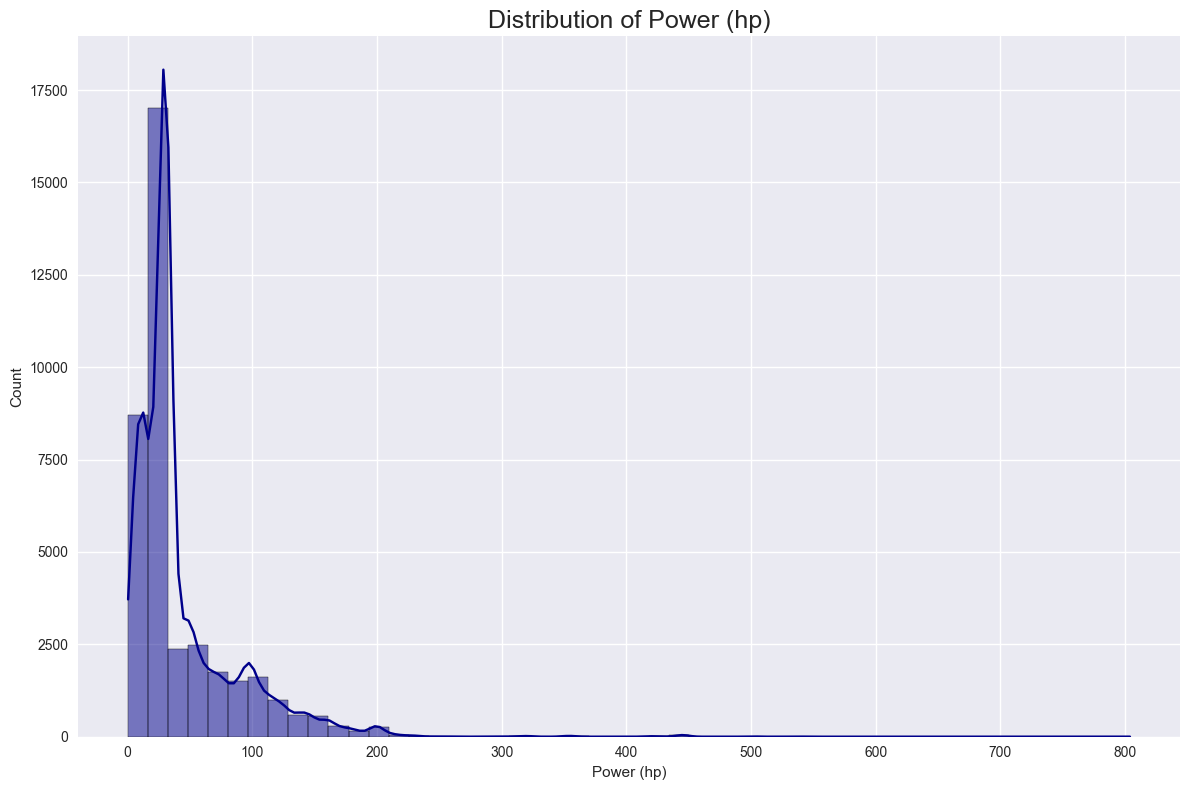

In [17]:
# توزیع قدرت موتورها
sns.histplot(data=df, x='Power (hp)', bins=50, kde=True, color='darkblue')
plt.title('Distribution of Power (hp)', fontsize=18)
plt.xlabel('Power (hp)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('1_power_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

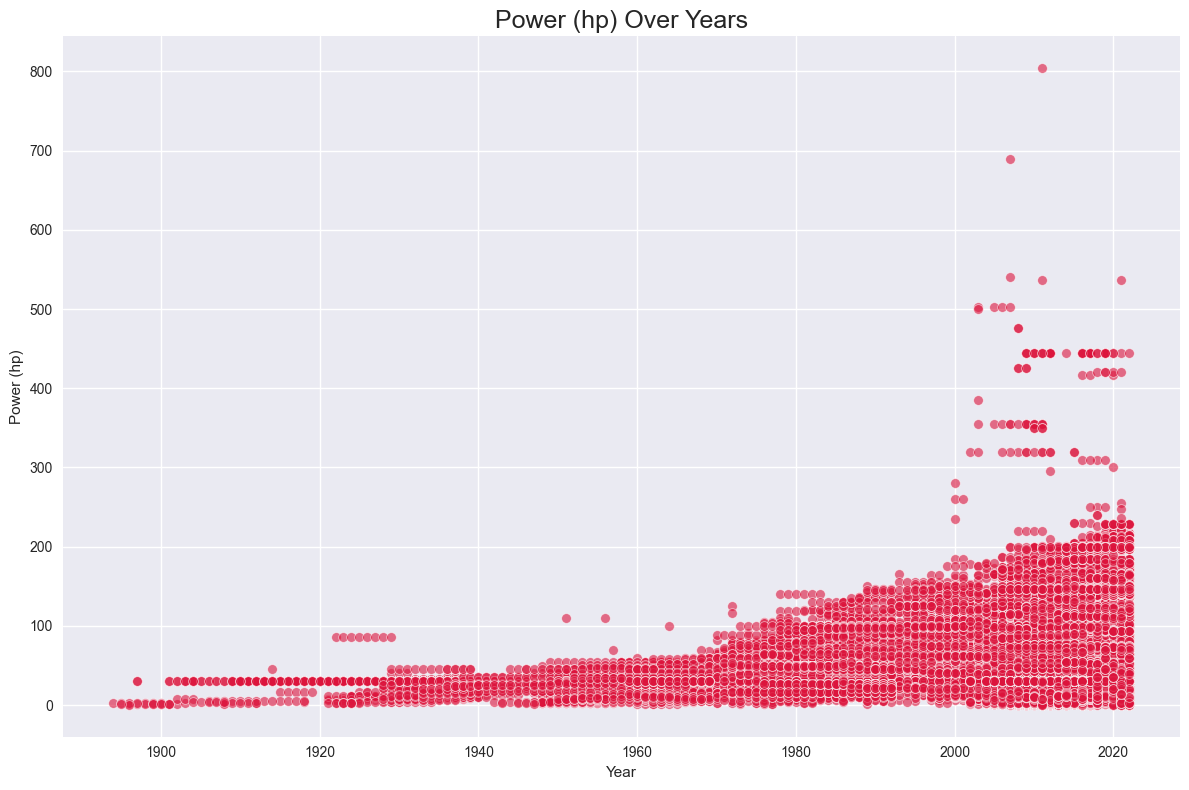

In [18]:
# قدرت موتورها چطور در طول زمان تغییر کرده؟
sns.scatterplot(data=df, x='Year', y='Power (hp)', alpha=0.6, color='crimson')
plt.title('Power (hp) Over Years', fontsize=18)
plt.xlabel('Year')
plt.ylabel('Power (hp)')
plt.tight_layout()
plt.savefig('2_power_vs_year.png', dpi=300, bbox_inches='tight')
plt.show()

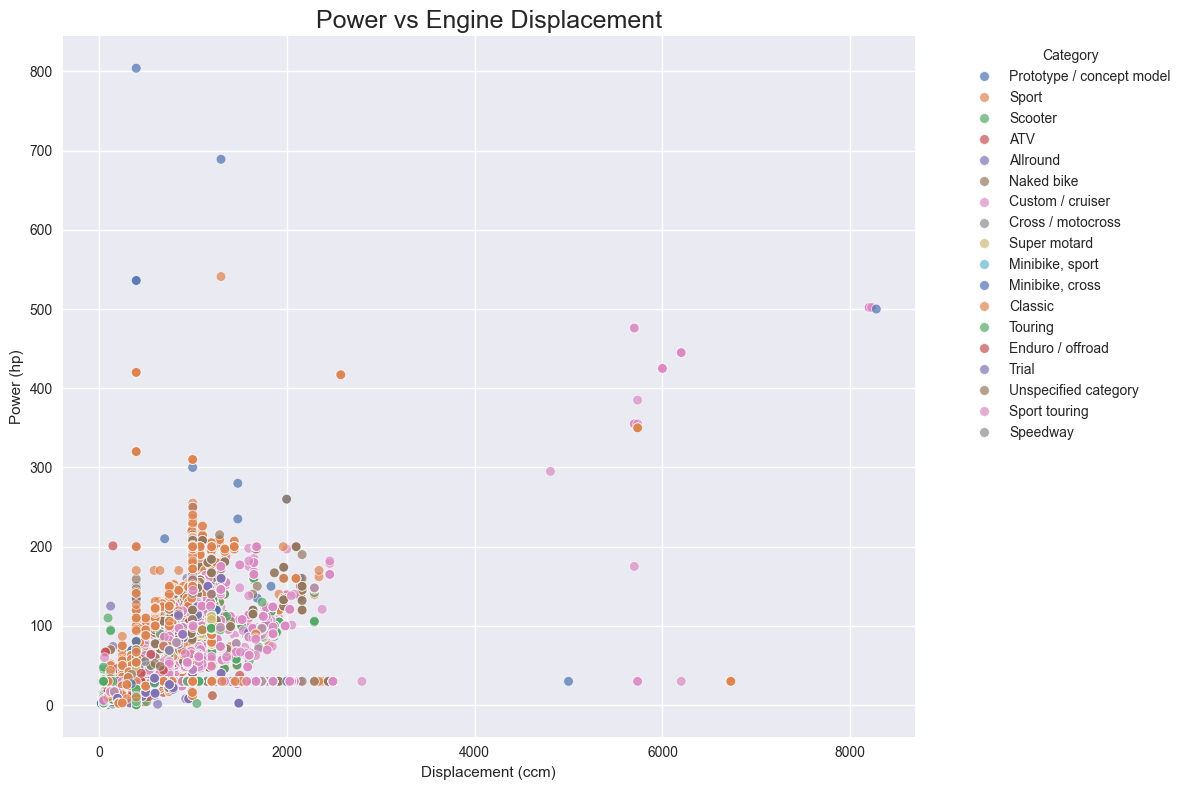

In [19]:
# حجم موتور بزرگ‌تر = قدرت بیشتر؟
sns.scatterplot(data=df, x='Displacement (ccm)', y='Power (hp)', alpha=0.7, hue='Category', palette='deep')
plt.title('Power vs Engine Displacement', fontsize=18)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('3_displacement_vs_power.png', dpi=300, bbox_inches='tight')
plt.show()

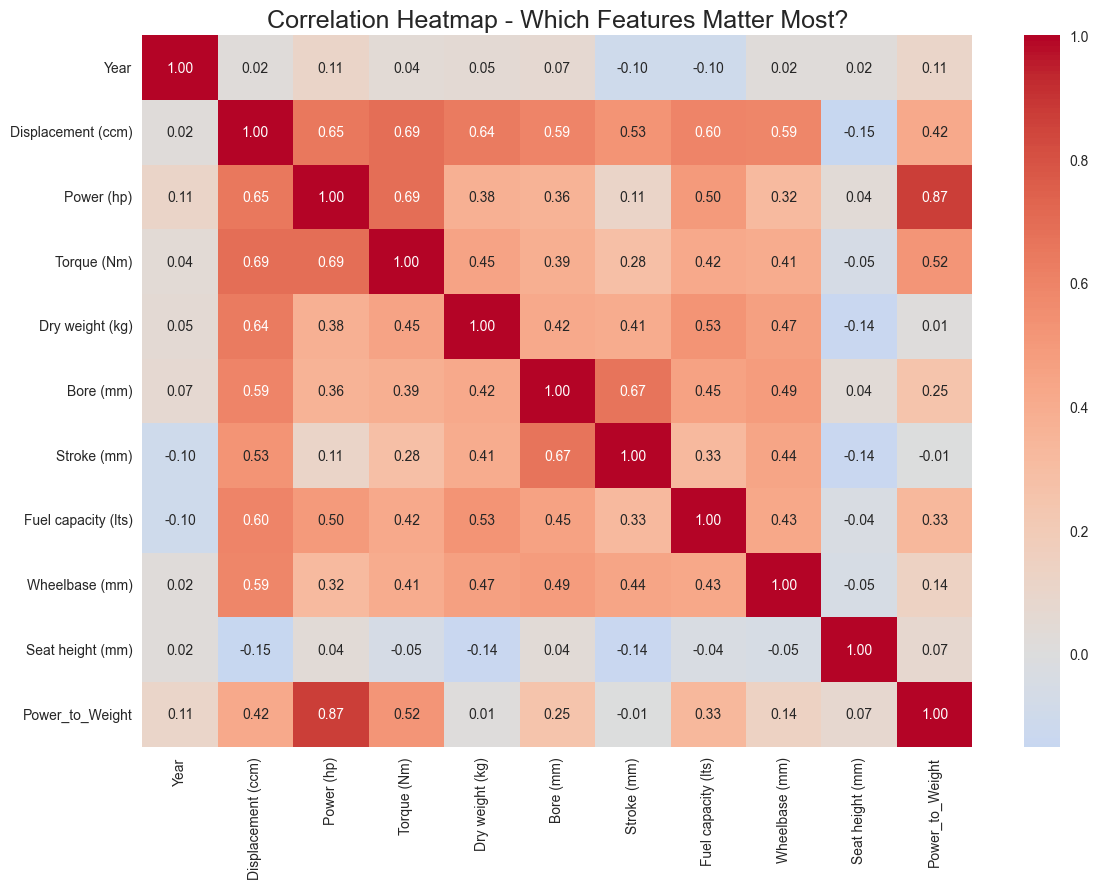

In [20]:
# کدوم فیچرها با قدرت موتور بیشترین ارتباط رو دارن؟
corr_cols = numeric_cols + ['Power_to_Weight']
plt.figure(figsize=(12,9))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap - Which Features Matter Most?', fontsize=18)
plt.tight_layout()
plt.savefig('4_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
# فیچرهای نهایی (بدون اسم مدل و برند که لیک دارن)
features = numeric_cols + ['Power_to_Weight']
X = df[features].copy()
y = df['Power (hp)']

print(f"تعداد فیچر: {X.shape[1]} تا")
print(f"تعداد نمونه: {X.shape[0]} تا")
print("داده آماده آموزش مدل شد!")

تعداد فیچر: 11 تا
تعداد نمونه: 38472 تا
داده آماده آموزش مدل شد!


In [31]:
from sklearn.model_selection import train_test_split

# ۸۰٪ آموزش، ۲۰٪ تست
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"آموزش: {len(X_train)} نمونه")
print(f"تست: {len(X_test)} نمونه")

آموزش: 28854 نمونه
تست: 9618 نمونه


In [33]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# مدل قوی و ساده (بدون تنظیم پیچیده)
model = CatBoostRegressor(iterations=1000, depth=6, learning_rate=0.05, verbose=200, random_seed=42)
model.fit(X_train, y_train)

# پیش‌بینی
y_pred = model.predict(X_test)

# ارزیابی
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"خطا: ±{mae:.1f} اسب بخار")
print(f"دقت مدل (R²): {r2:.6f} → خیلی خوبه!")

0:	learn: 41.6474419	total: 56.4ms	remaining: 56.4s
200:	learn: 1.3958927	total: 3.42s	remaining: 13.6s
400:	learn: 0.8305948	total: 7.16s	remaining: 10.7s
600:	learn: 0.6255152	total: 11.3s	remaining: 7.5s
800:	learn: 0.4910797	total: 14.5s	remaining: 3.6s
999:	learn: 0.4050020	total: 17.2s	remaining: 0us
خطا: ±0.3 اسب بخار
دقت مدل (R²): 0.996002 → خیلی خوبه!


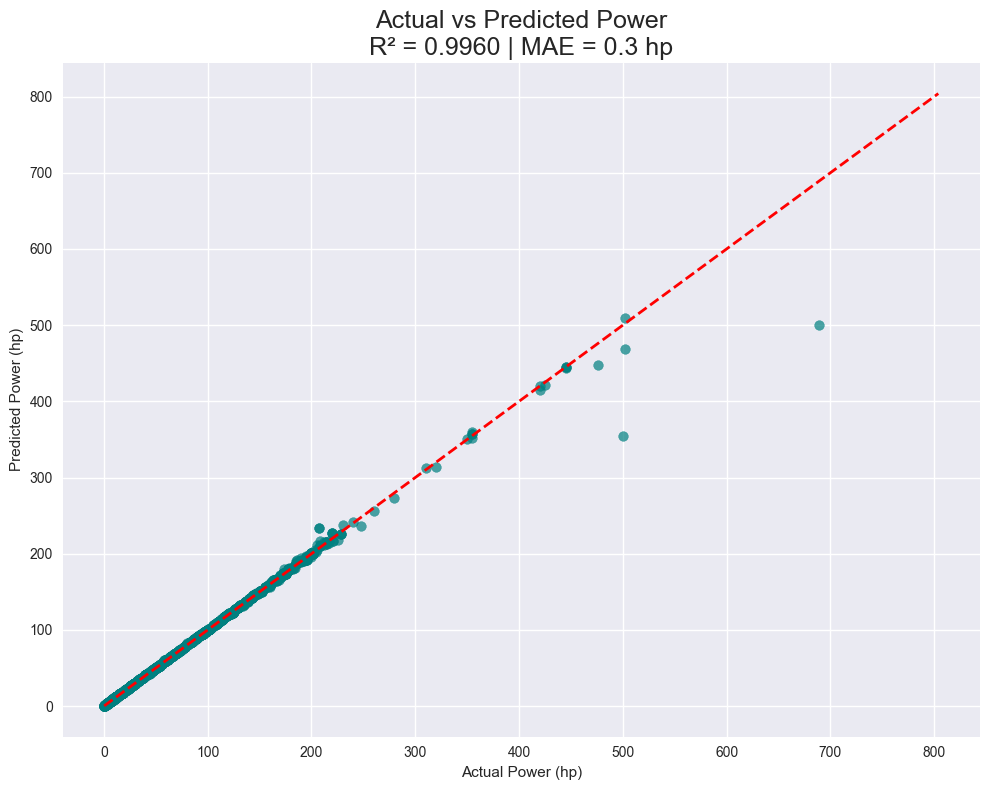

In [ ]:
plt.figure(figsize=(10,8))
plt.scatter(y_test, y_pred, alpha=0.7, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Power (hp)')
plt.ylabel('Predicted Power (hp)')
plt.title(f'Actual vs Predicted Power\nR² = {r2:.4f} | MAE = {mae:.1f} hp', fontsize=18)
plt.tight_layout()
plt.savefig('5_actual_vs_predicted_final.png', dpi=400, bbox_inches='tight')
plt.show()
